In [118]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore') # 성가신 경고창 숨기기

# ==========================================
# 1. 폰트 및 로드 함수 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac 사용자는 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

def load_csv(file_path):
    encodings = ['utf-8-sig', 'cp949', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"{file_path} 파일을 읽을 수 없습니다.")

# 데이터 불러오기 (경기도 BSI 및 지역화폐 3종)
df_bsi = load_csv('소상공인_지역별_실적_및_전망_20260323130511.csv')
df_1922 = load_csv('지역화폐발행및이용현황(2019~2022)_수정.csv')
df_23 = load_csv('지역화폐발행및이용현황(2023).csv')
df_2425 = load_csv('지역화폐발행및이용현황 (2).csv')

In [147]:

# ==========================================
# 2. 데이터 전처리
# ==========================================
# [1] 경기도 소상공인 연도별 매출체감(BSI) 산출
row_gg = df_bsi[df_bsi['지역별(1)'] == '경기']
type_row = df_bsi.iloc[0]
chegam_cols = type_row[type_row == '체감'].index



bsi_gg = row_gg[chegam_cols].copy().T.reset_index()
bsi_gg.columns = ['원본연월', 'BSI']
bsi_gg['Year'] = bsi_gg['원본연월'].str.split('.').str[0].astype(int)
bsi_gg['BSI'] = pd.to_numeric(bsi_gg['BSI'], errors='coerce')



# 연도별 BSI '평균' 계산
yearly_bsi = bsi_gg.groupby('Year')['BSI'].mean().reset_index()


df_1922 = df_1922.fillna(0)

# [2] 경기도 지역화폐 연도별 총 사용액 산출 (단위: 억원)
df_1922['사용액_억원'] = pd.to_numeric(df_1922['월별사용액(천원)'], errors='coerce').fillna(0) / 100000
df_23['사용액_억원'] = pd.to_numeric(df_23['월별사용액(백만원)'], errors='coerce').fillna(0) / 100
df_2425['사용액_억원'] = pd.to_numeric(df_2425['월별사용액(백만원)'], errors='coerce').fillna(0) / 100


df_1922 = df_1922[['시군명','기준년월', '월별사용액(천원)', '사용액_억원']]
df_23 = df_23[['시군명','기준년월', '월별사용액(백만원)', '사용액_억원']]
df_2425 = df_2425[['시군명','기준년월', '월별사용액(백만원)', '사용액_억원']]


curr_all = pd.concat([
    df_1922[['기준년월', '사용액_억원']],
    df_23[['기준년월', '사용액_억원']],
    df_2425[['기준년월', '사용액_억원']]
]).dropna(subset=['기준년월'])

curr_all['Year'] = curr_all['기준년월'].str.split('-').str[0].astype(int)

# 연도별 사용액 '총합' 계산
yearly_curr = curr_all.groupby('Year')['사용액_억원'].sum().reset_index()

# [3] 데이터 병합 (2019 ~ 2025년)
merged_df = pd.merge(yearly_bsi, yearly_curr, on='Year', how='inner')

df_bsi

,지역별(1),2017.01,2017.01.1,2017.02,2017.02.1,2017.03,2017.03.1,2017.04,2017.04.1,2017.05,...,2025.08.1,2025.09,2025.09.1,2025.10,2025.10.1,2025.11,2025.11.1,2025.12,2025.12.1,2026.01
0,지역별(1),체감,전망,체감,전망,체감,전망,체감,전망,체감,...,전망,체감,전망,체감,전망,체감,전망,체감,전망,전망
1,서울,61.5,79.0,60.1,82.8,75.1,83.0,72.2,92.3,74.9,...,75.2,80.3,89.3,81.1,87.7,72.9,91.0,71.1,81.6,76.2
2,부산,68.1,78.0,57.0,83.3,71.9,82.2,64.6,95.9,70.5,...,80.3,81.5,88.5,76.8,92.1,74.7,92.4,67.9,85.6,75.6
3,대구,68.2,80.6,57.3,83.4,75.2,83.1,64.2,93.4,70.2,...,73.3,75.3,87.3,76.0,85.0,77.0,94.7,70.0,87.3,75.0
4,인천,68.2,87.2,60.5,88.5,83.2,90.6,69.2,94.1,74.8,...,73.1,69.6,84.6,73.4,82.2,72.7,96.2,63.6,83.9,69.2
5,광주,71.2,77.8,49.1,88.1,76.5,82.7,73.9,92.5,81.4,...,84.5,81.4,94.7,80.5,90.7,74.3,93.4,75.7,79.2,78.8
6,대전,68.6,81.9,64.5,87.7,83.6,83.2,72.3,90.9,75.9,...,74.8,75.7,91.9,75.2,86.0,76.1,91.0,66.7,83.3,78.4
7,울산,63.6,73.9,44.9,84.8,72.7,83.8,50.0,78.8,59.6,...,67.7,66.1,76.0,81.3,74.0,80.2,93.8,72.9,85.9,81.3
8,세종,70.0,86.3,67.5,90.0,88.8,101.3,75.0,90.0,77.5,...,80.2,74.0,96.9,85.4,89.6,84.4,95.8,74.0,84.4,72.9
9,경기,61.7,81.5,58.6,84.5,81.9,87.6,68.8,93.3,75.9,...,79.9,75.6,93.4,78.9,87.3,75.7,87.5,70.3,85.0,76.4


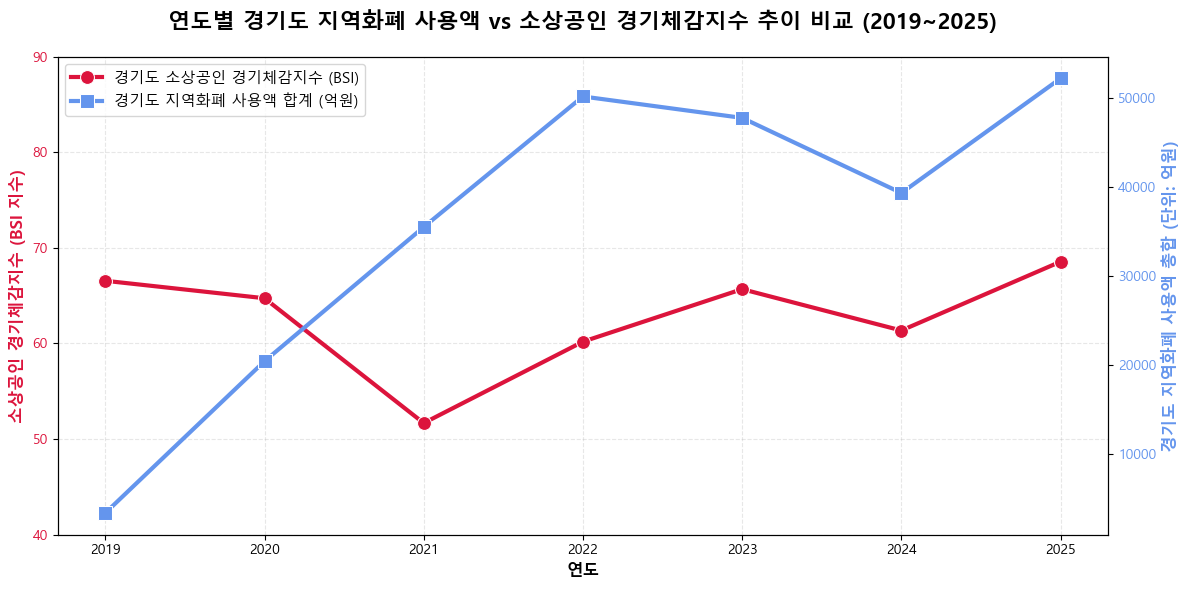

In [138]:
# ==========================================
# 3. 데이터 시각화 (좌우 축 변경 / 둘 다 선 그래프)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=merged_df, 
    x='Year', 
    y='BSI', 
    marker='o', 
    markersize=10,
    linewidth=3,
    color='crimson', 
    ax=ax1, 
    label='경기도 소상공인 경기체감지수 (BSI)'
)
ax1.set_xlabel('연도', fontsize=12, fontweight='bold')
ax1.set_ylabel('소상공인 경기체감지수 (BSI 지수)', fontsize=12, fontweight='bold', color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.set_ylim(40, 90) # BSI 변동폭 고정

ax2 = ax1.twinx()
sns.lineplot(
    data=merged_df, 
    x='Year', 
    y='사용액_억원', 
    marker='s', # 네모 마커
    markersize=10,
    linewidth=3,
    color='cornflowerblue', 
    ax=ax2, 
    label='경기도 지역화폐 사용액 합계 (억원)'
)
ax2.set_ylabel('경기도 지역화폐 사용액 총합 (단위: 억원)', fontsize=12, fontweight='bold', color='cornflowerblue')
ax2.tick_params(axis='y', labelcolor='cornflowerblue')

# 제목 및 그리드 설정
plt.title('연도별 경기도 지역화폐 사용액 vs 소상공인 경기체감지수 추이 비교 (2019~2025)', fontsize=16, fontweight='bold', pad=20)
ax1.grid(axis='both', linestyle='--', alpha=0.3)

# 두 범례(Legend) 합치기
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11, frameon=True)

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

plt.tight_layout()
plt.show()

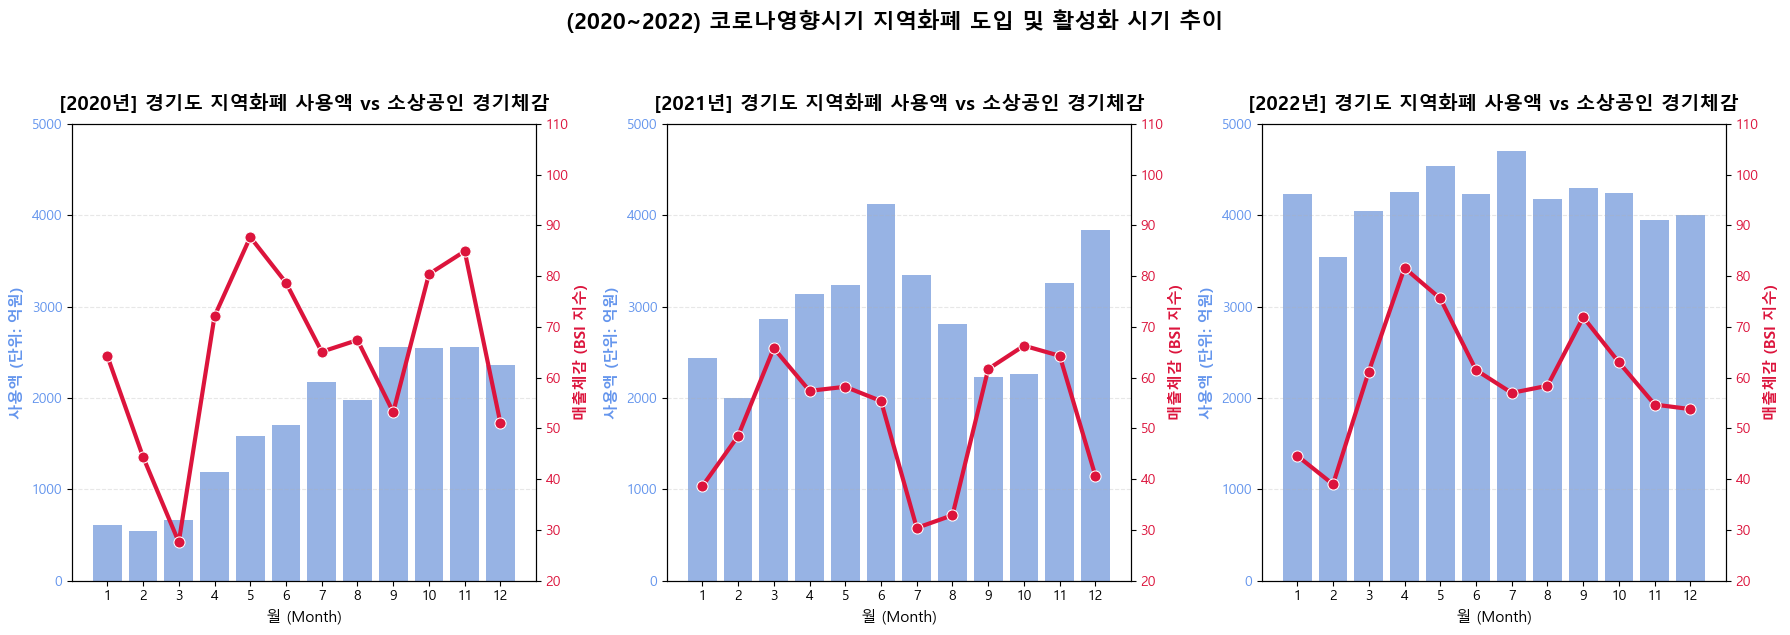

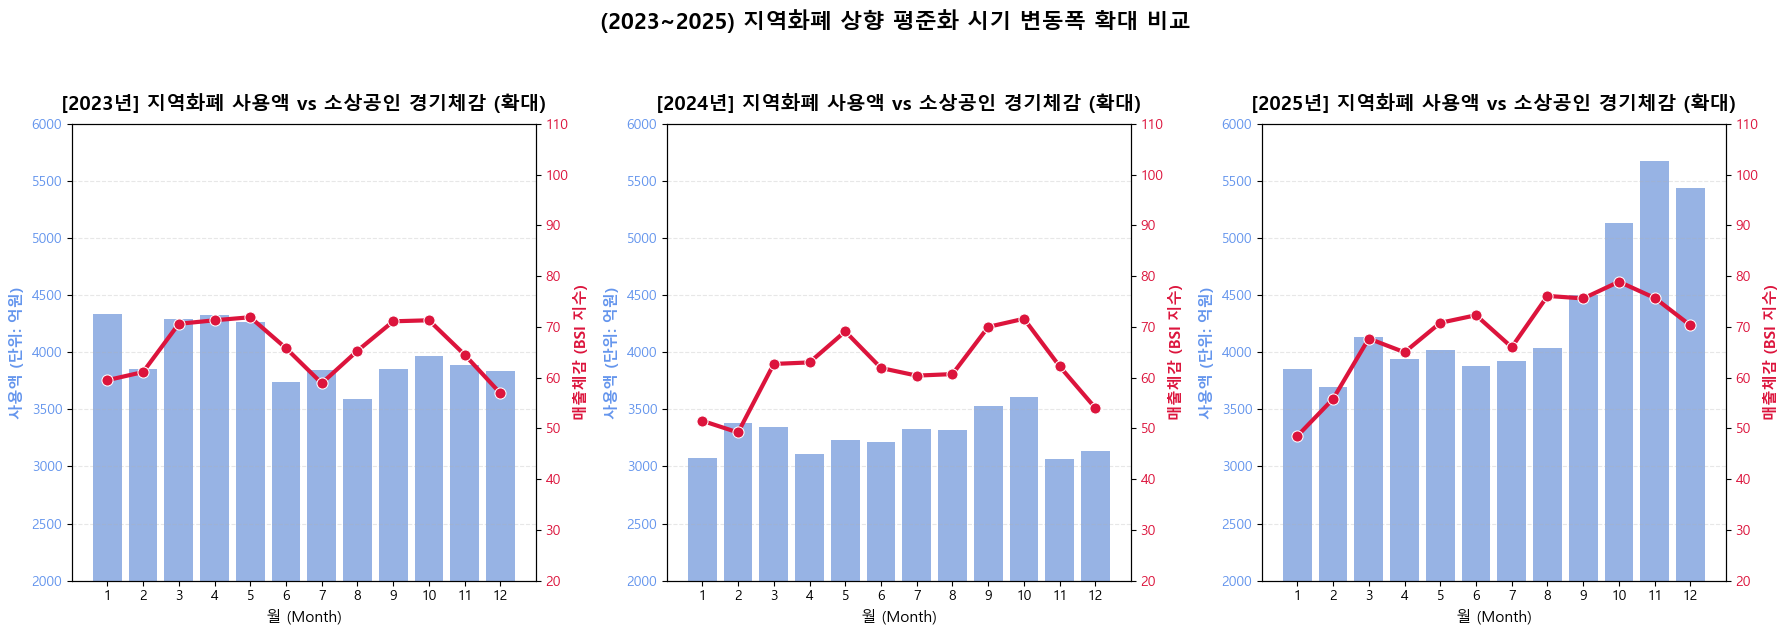

In [140]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore') # 성가신 경고창 숨기기

# ==========================================
# 1. 폰트 및 로드 함수 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac 사용자는 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

def load_csv(file_path):
    encodings = ['utf-8-sig', 'cp949', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"{file_path} 파일을 읽을 수 없습니다.")
    

# 데이터 불러오기
df_bsi = load_csv('소상공인_지역별_실적_및_전망_20260323130511.csv')
df_1922 = load_csv('지역화폐발행및이용현황(2019~2022)_수정.csv')
df_23 = load_csv('지역화폐발행및이용현황(2023).csv')
df_2425 = load_csv('지역화폐발행및이용현황 (2).csv')


# ==========================================
# 2. 데이터 전처리 (월별 매칭)
# ==========================================
# [BSI 전처리]
row_gg = df_bsi[df_bsi['지역별(1)'] == '경기']
type_row = df_bsi.iloc[0]
chegam_cols = type_row[type_row == '체감'].index
bsi_gg = row_gg[chegam_cols].copy().T.reset_index()
bsi_gg.columns = ['원본연월', 'BSI']
bsi_gg['Year'] = bsi_gg['원본연월'].str.split('.').str[0].astype(int)
bsi_gg['Month'] = bsi_gg['원본연월'].str.split('.').str[1].astype(int)
bsi_gg['BSI'] = pd.to_numeric(bsi_gg['BSI'], errors='coerce')

# [지역화폐 전처리] 단위 '억원' 통합
df_1922['사용액_억원'] = pd.to_numeric(df_1922['월별사용액(천원)'], errors='coerce') / 100000
df_23['사용액_억원'] = pd.to_numeric(df_23['월별사용액(백만원)'], errors='coerce') / 100
df_2425['사용액_억원'] = pd.to_numeric(df_2425['월별사용액(백만원)'], errors='coerce') / 100

curr_all = pd.concat([
    df_1922[['기준년월', '사용액_억원']],
    df_23[['기준년월', '사용액_억원']],
    df_2425[['기준년월', '사용액_억원']]
]).dropna(subset=['기준년월'])

curr_all['Year'] = curr_all['기준년월'].str.split('-').str[0].astype(int)
curr_all['Month'] = curr_all['기준년월'].str.split('-').str[1].astype(int)
curr_grouped = curr_all.groupby(['Year', 'Month'])['사용액_억원'].sum().reset_index()

# [병합 및 2020~2025 필터링]
merged_df = pd.merge(curr_grouped, bsi_gg[['Year', 'Month', 'BSI']], on=['Year', 'Month'], how='inner')
merged_df = merged_df[merged_df['Year'].between(2020, 2025)]


# ==========================================
# 3. 데이터 시각화
# ==========================================

# --------------------------------------------------
# 파트 A: 2020년 ~ 2022년 (1행 3열 나란히 배치, Y축 0~5000 고정)
# --------------------------------------------------
years_early = [2020, 2021, 2022]
fig1, axes1 = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, year in enumerate(years_early):
    ax1 = axes1[i]
    data_year = merged_df[merged_df['Year'] == year].sort_values('Month')
    
    # 막대 그래프
    sns.barplot(data=data_year, x='Month', y='사용액_억원', color='cornflowerblue', alpha=0.75, ax=ax1)
    ax1.set_title(f'[{year}년] 경기도 지역화폐 사용액 vs 소상공인 경기체감', fontsize=14, fontweight='bold', pad=10)
    ax1.set_xlabel('월 (Month)', fontsize=11)
    ax1.set_ylabel('사용액 (단위: 억원)', fontsize=11, fontweight='bold', color='cornflowerblue')
    ax1.tick_params(axis='y', labelcolor='cornflowerblue')
    
    # ★ 전체 규모 비교를 위해 Y축 0 ~ 5000 강제 고정
    ax1.set_ylim(0, 5000)
    
    # 선 그래프
    ax2 = ax1.twinx()
    sns.lineplot(x=range(len(data_year)), y=data_year['BSI'], marker='o', markersize=8, linewidth=3, color='crimson', ax=ax2)
    ax2.set_ylabel('매출체감 (BSI 지수)', fontsize=11, fontweight='bold', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    ax2.set_ylim(20, 110) # BSI 지수 고정
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('(2020~2022) 코로나영향시기 지역화폐 도입 및 활성화 시기 추이', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 파트 B: 2023년 ~ 2025년 (1행 3열 나란히 배치, Y축 2000~6000 확대 고정)
# --------------------------------------------------
years_later = [2023, 2024, 2025]
fig2, axes2 = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, year in enumerate(years_later):
    ax1 = axes2[i]
    data_year = merged_df[merged_df['Year'] == year].sort_values('Month')
    
    # 막대 그래프
    sns.barplot(data=data_year, x='Month', y='사용액_억원', color='cornflowerblue', alpha=0.75, ax=ax1)
    ax1.set_title(f'[{year}년] 지역화폐 사용액 vs 소상공인 경기체감 (확대)', fontsize=14, fontweight='bold', pad=10)
    ax1.set_xlabel('월 (Month)', fontsize=11)
    ax1.set_ylabel('사용액 (단위: 억원)', fontsize=11, fontweight='bold', color='cornflowerblue')
    ax1.tick_params(axis='y', labelcolor='cornflowerblue')
    
    # ★ 미세 변동폭 확인을 위해 Y축 2000 ~ 6000 강제 고정 (돋보기 효과)
    ax1.set_ylim(2000, 6000)
    
    # 선 그래프
    ax2 = ax1.twinx()
    sns.lineplot(x=range(len(data_year)), y=data_year['BSI'], marker='o', markersize=8, linewidth=3, color='crimson', ax=ax2)
    ax2.set_ylabel('매출체감 (BSI 지수)', fontsize=11, fontweight='bold', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    ax2.set_ylim(20, 110) # BSI 지수 고정
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('(2023~2025) 지역화폐 상향 평준화 시기 변동폭 확대 비교', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

📊 [최근 3년 월별 데이터] 상관계수: 0.579



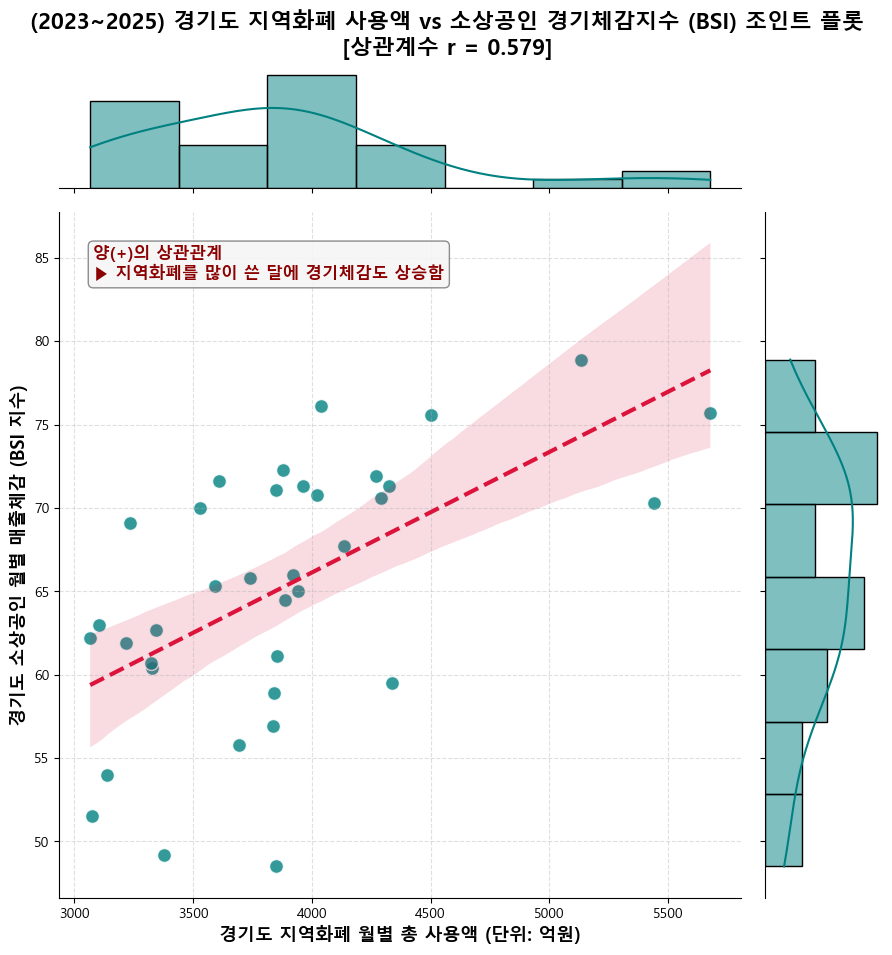

In [146]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore') # 성가신 경고창 숨기기

# ==========================================
# 1. 폰트 및 로드 함수 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac 사용자는 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

def load_csv(file_path):
    encodings = ['utf-8-sig', 'cp949', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"{file_path} 파일을 읽을 수 없습니다.")

# 데이터 불러오기
df_bsi = load_csv('소상공인_지역별_실적_및_전망_20260323130511.csv')
df_1922 = load_csv('지역화폐발행및이용현황(2019~2022)_수정.csv')
df_23 = load_csv('지역화폐발행및이용현황(2023).csv')
df_2425 = load_csv('지역화폐발행및이용현황 (2).csv')


# ==========================================
# 2. 데이터 전처리 (월별 매칭)
# ==========================================
# [BSI 전처리] 경기도 추출
row_gg = df_bsi[df_bsi['지역별(1)'] == '경기']
type_row = df_bsi.iloc[0]
chegam_cols = type_row[type_row == '체감'].index

bsi_gg = row_gg[chegam_cols].copy().T.reset_index()
bsi_gg.columns = ['원본연월', 'BSI']
bsi_gg['Year'] = bsi_gg['원본연월'].str.split('.').str[0].astype(int)
bsi_gg['Month'] = bsi_gg['원본연월'].str.split('.').str[1].astype(int)
bsi_gg['BSI'] = pd.to_numeric(bsi_gg['BSI'], errors='coerce')

# [지역화폐 전처리] 단위 '억원' 통일
df_1922['사용액_억원'] = pd.to_numeric(df_1922['월별사용액(천원)'], errors='coerce') / 100000
df_23['사용액_억원'] = pd.to_numeric(df_23['월별사용액(백만원)'], errors='coerce') / 100
df_2425['사용액_억원'] = pd.to_numeric(df_2425['월별사용액(백만원)'], errors='coerce') / 100

curr_all = pd.concat([
    df_1922[['기준년월', '사용액_억원']],
    df_23[['기준년월', '사용액_억원']],
    df_2425[['기준년월', '사용액_억원']]
]).dropna(subset=['기준년월'])

curr_all['Year'] = curr_all['기준년월'].str.split('-').str[0].astype(int)
curr_all['Month'] = curr_all['기준년월'].str.split('-').str[1].astype(int)

# 31개 시군 월별 총합 계산
curr_grouped = curr_all.groupby(['Year', 'Month'])['사용액_억원'].sum().reset_index()

# [병합] 연도와 월을 기준으로 병합 후 2023~2025년 필터링
merged_df = pd.merge(curr_grouped, bsi_gg[['Year', 'Month', 'BSI']], on=['Year', 'Month'], how='inner')
data_recent = merged_df[merged_df['Year'].isin([2023, 2024, 2025])]


# ==========================================
# 3. 상관계수 계산 및 조인트 플롯 시각화
# ==========================================
# 상관계수 계산 (Pearson)
corr_recent = data_recent['사용액_억원'].corr(data_recent['BSI'])

print("==================================================")
print(f"📊 [최근 3년 월별 데이터] 상관계수: {corr_recent:.3f}")
print("==================================================\n")

# 조인트 플롯 생성 (kind='reg'를 통해 회귀선과 분포도 동시 생성)
g = sns.jointplot(
    data=data_recent, 
    x='사용액_억원', 
    y='BSI', 
    kind='reg',           # 산점도 + 회귀선 + 히스토그램/KDE
    color='teal',
    height=9,             # 그래프 전체 크기
    ratio=5,              # 가운데 산점도와 바깥쪽 분포도의 크기 비율
    scatter_kws={'alpha':0.8, 's':100, 'edgecolor':'white'}, 
    line_kws={'color':'crimson', 'linewidth':3, 'linestyle':'--'}
)

# 제목 설정 (조인트 플롯은 전체 Figure에 suptitle을 달아야 합니다)
g.figure.suptitle(f'(2023~2025) 경기도 지역화폐 사용액 vs 소상공인 경기체감지수 (BSI) 조인트 플롯\n[상관계수 r = {corr_recent:.3f}]', 
                  fontsize=16, fontweight='bold', y=1.05) # y=1.05로 주어 제목이 그래프와 겹치지 않게 함

# 축 라벨 설정
g.set_axis_labels('경기도 지역화폐 월별 총 사용액 (단위: 억원)', '경기도 소상공인 월별 매출체감 (BSI 지수)', 
                  fontsize=13, fontweight='bold')

# 그리드 추가 (메인 산점도 영역에만)
g.ax_joint.grid(linestyle='--', alpha=0.4)

# 텍스트 박스로 통계적 해석 달기
interpretation = ""
if corr_recent > 0.3:
    interpretation = "양(+)의 상관관계\n▶ 지역화폐를 많이 쓴 달에 경기체감도 상승함"

props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.9, edgecolor='gray')
g.ax_joint.text(0.05, 0.95, interpretation, transform=g.ax_joint.transAxes, fontsize=12,
                verticalalignment='top', bbox=props, fontweight='bold', color='darkred')

plt.show()

In [129]:
curr_grouped

,Year,Month,사용액_억원
0,2019,1,39.63836
1,2019,2,35.57059
2,2019,3,48.06588
3,2019,4,68.28747
4,2019,5,228.52964
...,...,...,...
79,2025,8,4038.43000
80,2025,9,4502.65000
81,2025,10,5134.69000
82,2025,11,5676.77000
